<a href="https://colab.research.google.com/github/dsl-unibe-ch/machine-learning/blob/master/5_ML_UL_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine learning - Unsupervised Learning

**Lecturer:** Ana Stojiljkovic, DVM PhD  
Data Science Lab, University of Bern | 2026

---

*Based on the original teaching materials developed by Mykhailo Vladymyrov and Aris Marcolongo, Data Science Lab, University of Bern (2023).*

*Original material: [DSF5 GitHub repository](https://github.com/neworldemancer/DSF5).*

*This work is licensed under [CC0 1.0 Universal](https://creativecommons.org/publicdomain/zero/1.0/).*



## 1. Learning outcomes

By the end of this session, you will be able to:

- Explain what clustering is and how it differs from supervised learning.
- Apply **K-means** and use the **silhouette score** to explore different numbers of clusters.
- Interpret a **dendrogram** and explain how hierarchical clustering reveals relationships between observations or features.
- Distinguish **hard clustering** from **soft clustering** using Gaussian mixture models and their cluster probabilities.
- Explain why **feature scaling, distance measures, and domain knowledge** matter when interpreting clustering results.

## 2. Clustering vs Dimensionality Reduction

In the previous session, we used **PCA, t-SNE, and UMAP** to explore high-dimensional data. These methods give us new coordinates that make patterns easier to examine. But a visualization does not, by itself, tell us which observations belong to the same group.

**Clustering** addresses a different question: *Can we identify groups of similar observations in our data?*

| Dimensionality reduction | Clustering |
|---|---|
| Produces new coordinates for each observation | Identifies groups of observations |
| Helps summarize or visualize variation | Helps explore similarities and differences between groups |
| Examples: PCA, t-SNE, UMAP | Examples: K-means, hierarchical clustering, HDBSCAN |

Both belong to **unsupervised learning**. We can also combine them—as we did with UMAP and HDBSCAN in the Ames Housing exercise.

![Machine learning algorithm selection guide](figures/cheatsheet.png)

*Source: [scikit-learn algorithm selection guide](https://scikit-learn.org/stable/machine_learning_map.html).*


### Clustering objective

We start with a dataset containing \(N\) observations, each described by \(D\) features. A clustering algorithm aims to identify groups of observations with similar characteristics.

In **hard clustering**, each observation \(p\) is assigned a cluster label:

$$
l_p \in \{1, \ldots, K\}
$$

where \(K\) is the number of clusters. Other approaches can assign probabilities of belonging to different groups or leave some observations unassigned.

### An important consideration: What makes observations similar?

Many clustering methods rely on distances between observations. A common choice is **Euclidean distance**:

$$
d(x_p, x_q) = \sqrt{\sum_{i=1}^{D}(x_{p,i}-x_{q,i})^2}
$$

Distances depend on the scales of the features. For example, a variable measured in thousands can dominate another measured from 1 to 10. **Feature scaling** is therefore often important, although the appropriate preprocessing depends on the data and method.

Different methods also make different assumptions about what constitutes a group. Clustering is an **exploratory process**: we need to examine the results, try appropriate settings, and use domain knowledge to decide whether the identified groups are useful.

**Remember:** If a dataset already has class labels, its clusters do not necessarily correspond to those classes—or even have the same number.

## Load the libraries

In [ ]:
# For colab users
#!pip install umap-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, fetch_openml

from sklearn.preprocessing import StandardScaler
import umap

from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster

from ipywidgets import interact

from scipy.stats import entropy

import os
import tarfile

In [3]:
from utils.routines import *

In [4]:
from pathlib import Path
from urllib.request import urlretrieve
import tarfile
import shutil
import sys

def download_and_extract_data(
    url="https://github.com/dsl-unibe-ch/machine-learning/raw/master/colab_material.tgz",
    target_dir="data",
    update_folder=False,
):
    target_dir = Path(target_dir)

    if update_folder and target_dir.exists():
        shutil.rmtree(target_dir)

    if not target_dir.exists():
        archive_path = Path("colab_material.tgz")

        print("Downloading data...")
        urlretrieve(url, archive_path)

        target_dir.mkdir(parents=True, exist_ok=True)

        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(target_dir, filter="data")

        archive_path.unlink()

    else:
        print("Data already present.")

    return target_dir.resolve()


data_path = download_and_extract_data(update_folder=False)
sys.path.append(str(data_path))

Data already present.


In [5]:
import pickle

def get_nlp_dataset(data_path):
    data=pickle.load(open(f'{data_path}/cluster_nlp.pkl', 'rb'))
    vectors=data['embeddings']
    texts=data['texts']
    return texts, vectors

def get_customers_dataset(data_path):
    X_customers = pd.read_csv(f'{data_path}/X_customers.csv')
    return X_customers

In [6]:
from pathlib import Path
from urllib.request import urlretrieve
import tarfile
import pickle
import pandas as pd

archive_url = (
    "https://github.com/dsl-unibe-ch/machine-learning/"
    "raw/master/colab_material.tgz"
)

# Download and extract the course data only if needed
data_dir = Path("data")

if not list(data_dir.rglob("cluster_nlp.pkl")):
    archive_path = Path("colab_material.tgz")
    urlretrieve(archive_url, archive_path)

    data_dir.mkdir(exist_ok=True)
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(data_dir, filter="data")

# Locate the folder containing the exercise datasets
data_path = next(data_dir.rglob("cluster_nlp.pkl")).parent
print("Dataset folder:", data_path)

Dataset folder: data


## 3. K-Means

### 3.1 Cluster Centers

The ***K-means*** clustering method heavily relies on the concept of `cluster centers`. Each group gets assigned a cluster center, as a mean representative point. The centroids given by the expression:
$$\mathbf{c}_k=\frac{1}{N_k}\sum_{p \in S_k} \mathbf{x_p}$$

$S_k$ is the subset of points assigned to the same group $k$ and $N_k$ is the number of points in $S_k$.

If the data cloud is made of images, it is the image containing at each pixel the mean value of all images of that group.

If the data cloud is made of questionnaires, it is the mean value assigned to an answer by all questionnaires belonging to that group.

If the data cloud is made of pressure sensors, it assigns to each sensors the mean of the pressure over all time spans belonging to that group, and so on...

***K-means*** assigns each data point to the cluster whose centre (centroid) is closest to it.

It then recalculates the centroids from the newly assigned points and repeats these two steps until the assignments or centroids stabilize.

### 3.2 The K-means loss function
But how do we know whether one clustering solution is better than another?

K-means aims to keep points **as close as possible to the centre of their assigned cluster**. It does this by minimizing the *within-cluster sum of squares*:

$$
\sum_{k=1}^{K} \sum_{p \in S_k} d(\mathbf{x}_p,\mathbf{c}_k)^2
$$

Here, $S_k$ is the set of points assigned to cluster $k$, and $\mathbf{c}_k$ is its centroid. Standard K-means uses **Euclidean distance**:

$$
d(\mathbf{x}_p,\mathbf{c}_k)
= \sqrt{\sum_{i=1}^{D}(x_{p,i}-c_{k,i})^2}
$$

A lower loss means that points are, overall, closer to their assigned centroids.

**Why does initialization matter?** Different starting centroids can lead to different final clusters. K-means may settle on a stable solution that is not the one with the lowest possible loss—a *local minimum*. To reduce this risk, we can run the algorithm several times with different initial centroids and keep the solution with the lowest loss.

### 3.3 Choosing the number of clusters: Silhouette score

K-means requires us to specify the **number of clusters, \(K\)**, in advance. But how do we choose an appropriate value?

One approach is to run K-means with different values of \(K\) and compare their [**silhouette scores**](https://en.wikipedia.org/wiki/Silhouette_(clustering)). The silhouette score considers two things:

- **Cohesion:** How close is a point to other points in its own cluster?
- **Separation:** How far is that point from points in the nearest other cluster?

The score ranges from **−1 to 1**. Higher values generally indicate clusters that are more compact and better separated. We can compare the average silhouette scores for different values of \(K\) to help choose the number of clusters.

**Remember:** A high silhouette score does not guarantee that the clusters are meaningful. We should also examine the results and consider our knowledge of the dataset.


<h3 style="color: #ff0000;">
  K-means on synthetic data
</h3>

Let’s start with a simple example using synthetic data generated by a helper function in this repository’s utils folder. We will apply K-means and visualize the resulting clusters.

In [7]:
from utils.routines import *
points=km_load_th1()

In [8]:
print(points.shape)
print('We have ', points.shape[0], 'points with two features')

(120, 2)
We have  120 points with two features


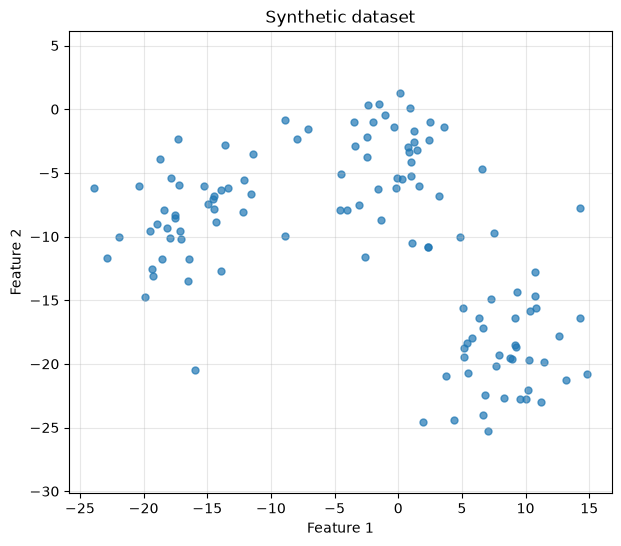

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(points[:, 0], points[:, 1], s=25, alpha=0.7)

ax.set(
    title="Synthetic dataset",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

plt.show()

The scatter plot of the two features suggests three groups, so we start by setting \(K=3\).

We first create a `KMeans` model and specify its parameters. **The data are not passed to the model yet**—we provide them in the next step, when we call `fit()`.

In [10]:
from sklearn.cluster import KMeans
clusterer = KMeans(n_clusters=3, random_state=10, n_init=10)

A call to the fit method computes the cluster centers which can be plotted alongside the data-set. They are accessible from the cluster_centers_ attribute:

In [11]:
clusterer.fit(points)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[[ 8.

As discussed earlier, K-means is an **optimization algorithm** that aims to minimize the within-cluster sum of squared distances between points and their centroids. Because different starting positions can lead to different local minima, we set `n_init=10` to run K-means with 10 different initializations and keep the solution with the **lowest loss**.

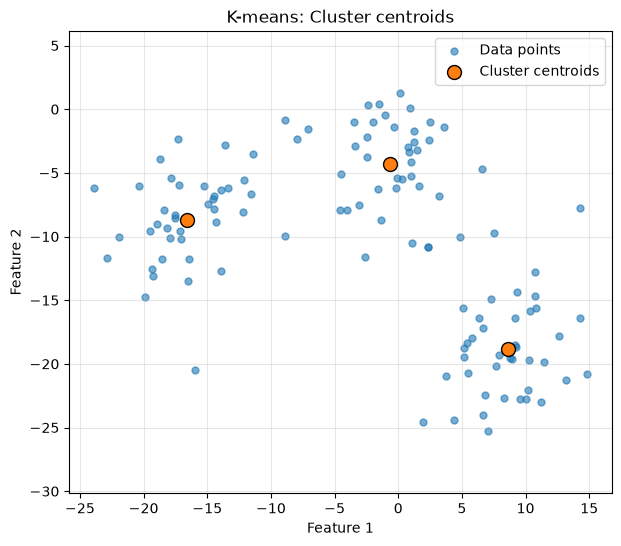

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(points[:, 0], points[:, 1], s=25, alpha=0.6, label="Data points")

ax.scatter(
    clusterer.cluster_centers_[:, 0],
    clusterer.cluster_centers_[:, 1],
    marker="o",
    s=100,
    edgecolors="black",
    linewidths=1,
    label="Cluster centroids",
)

ax.set(
    title="K-means: Cluster centroids",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

In [13]:
# Display the coordinates of the cluster centroids
clusterer.cluster_centers_[:,:]

array([[  8.5901409 , -18.82448838],
       [-16.59659661,  -8.6652939 ],
       [ -0.62089021,  -4.27748903]])

Now that K-means has found the coordinates of the three centroids, we can examine how well they represent the groups in our data.

Once we are satisfied with the clustering, we can use `predict()` to **assign new points to their nearest centroid**. We can also apply it to the points we used to fit the model, giving each one a cluster label. Let's do that and **color the points by their assigned cluster**.

In [14]:
cluster_labels=clusterer.predict(points)

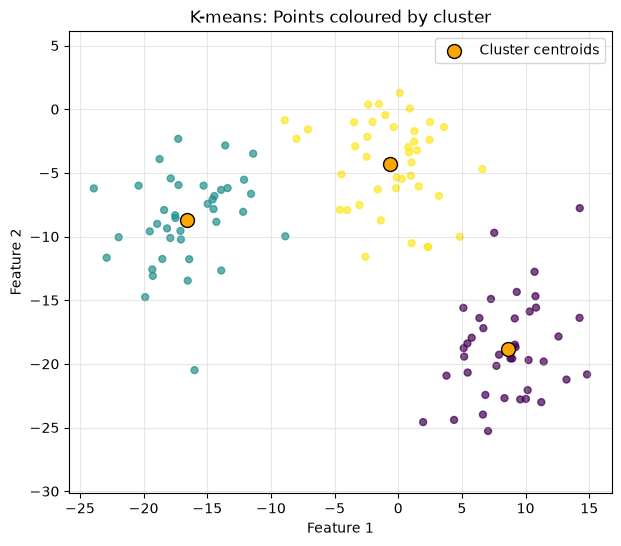

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(
    points[:, 0],
    points[:, 1],
    c=cluster_labels,
    s=25,
    alpha=0.7,
)

ax.scatter(
    clusterer.cluster_centers_[:, 0],
    clusterer.cluster_centers_[:, 1],
    marker="o",
    color="orange",
    s=100,
    edgecolors="black",
    linewidths=1,
    label="Cluster centroids",
)

ax.set(
    title="K-means: Points coloured by cluster",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

#### K-means decision regions
K-means assigns each observation to the **nearest centroid**. This means that K-means does not only cluster the observed data points: it also **partitions the entire feature space** into regions. Any new point would be assigned to the cluster whose centroid is closest.

In two dimensions, this partition is a **Voronoi tessellation**: each centroid defines one Voronoi region containing all points that are closer to that centroid than to any other.

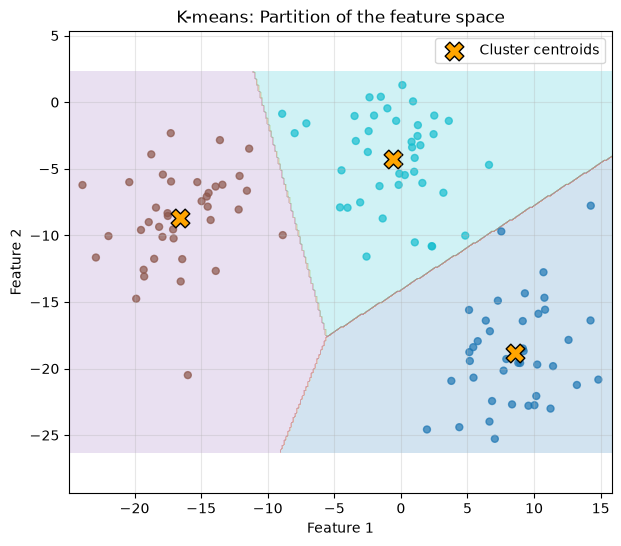

In [17]:

# Fit K-means
clusterer = KMeans(n_clusters=3, random_state=10, n_init=10)
cluster_labels = clusterer.fit_predict(points)

# Create a grid covering the data range (we approximate the plane with a finite mesh of points)
x_min, x_max = points[:, 0].min() - 1, points[:, 0].max() + 1
y_min, y_max = points[:, 1].min() - 1, points[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predict cluster assignment for every grid point
grid_labels = clusterer.predict(grid).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Decision regions
ax.contourf(
    xx,
    yy,
    grid_labels,
    alpha=0.2,
    cmap="tab10"
)

# Original points
scatter = ax.scatter(
    points[:, 0],
    points[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=25,
    alpha=0.7,
)

# Centroids
ax.scatter(
    clusterer.cluster_centers_[:, 0],
    clusterer.cluster_centers_[:, 1],
    marker="X",
    color="orange",
    s=180,
    edgecolors="black",
    linewidths=1,
    label="Cluster centroids",
)

ax.set(
    title="K-means: Partition of the feature space",
    xlabel="Feature 1",
    ylabel="Feature 2",
)

ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

#### Silhouette scores
To explore how the number of clusters affects the result, we run K-means for different values of \(K\) and compare the corresponding **silhouette scores**.

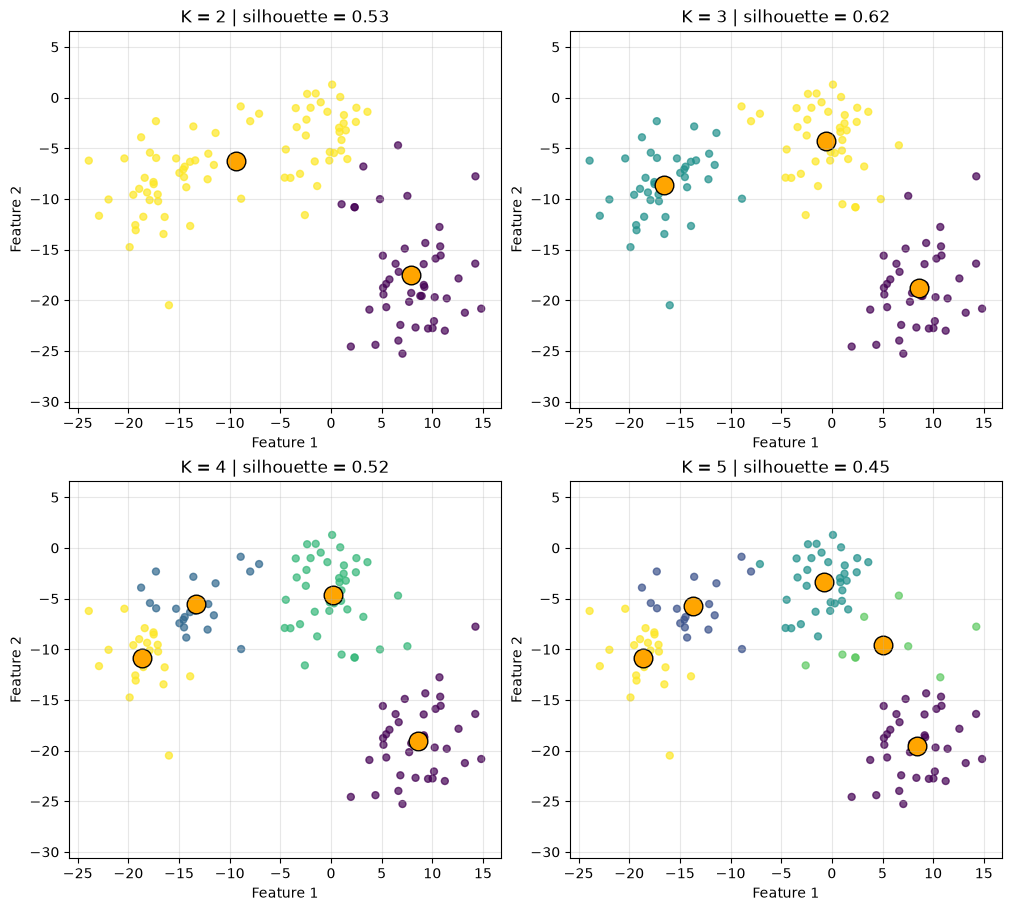

In [18]:
from sklearn.metrics import silhouette_score

sil = []
k_values = range(2, 6)

fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)

for ax, iclust in zip(axes.flat, k_values):
    clusterer = KMeans(n_clusters=iclust, random_state=10, n_init=10)
    cluster_labels = clusterer.fit_predict(points)

    score = silhouette_score(points, cluster_labels)
    sil.append(score)

    ax.scatter(
        points[:, 0],
        points[:, 1],
        c=cluster_labels,
        s=25,
        alpha=0.7,
    )

    ax.scatter(
        clusterer.cluster_centers_[:, 0],
        clusterer.cluster_centers_[:, 1],
        marker="o",
        s=180,
        color="orange",
        edgecolors="black",
        linewidths=1,
    )

    ax.set_title(f"K = {iclust} | silhouette = {score:.2f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(alpha=0.3)

plt.show()

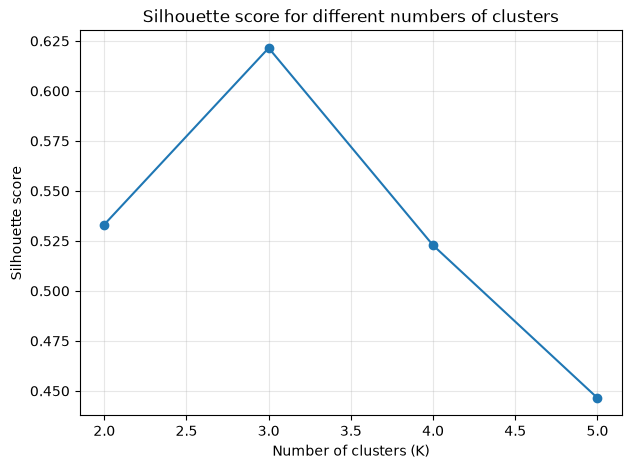

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(list(k_values), sil, "-o")

ax.set(
    title="Silhouette score for different numbers of clusters",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)
ax.grid(alpha=0.3)

plt.show()

<h3 style="color: #ff0000;">
  K-means on the Fashion MNIST dataset
</h3>

The same clustering techniques can also be applied to **high-dimensional datasets**.

Here, we use the **Fashion-MNIST** dataset, which contains 28 × 28 grayscale images of clothing items. Each image is flattened into a vector of 784 pixel features, and K-means is **applied directly in this 784-dimensional feature space**.

In [ ]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml(
    "Fashion-MNIST",
    as_frame=False,
    return_X_y=True
)

X = X / 255.0

train_images = X.reshape(-1, 28, 28)
train_labels = y.astype(int)

print(train_images.shape)

(70000, 28, 28)


In [21]:
# Select a subset of the data for clustering
n_examples = 5000

data = X[:n_examples]
labels = y[:n_examples]

(5000, 784)


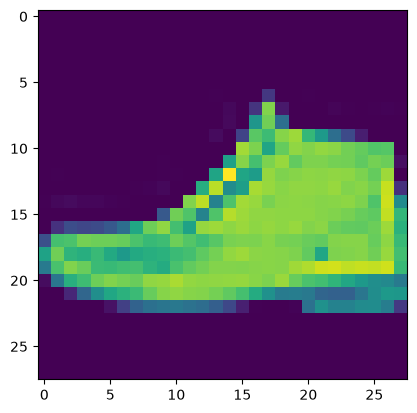

In [22]:
print(data.shape)
image=X[1232,:].reshape(28,28)
plt.imshow(image)

We know that in the dataset there are 10 clothing categories so it makes sense to define K=10 for the first attempt of clustering. 

In [25]:
clusterer = KMeans(n_clusters=10, random_state=10, n_init=50)
cluster_labels = clusterer.fit_predict(data)

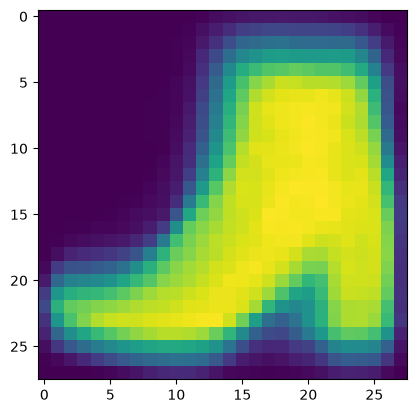

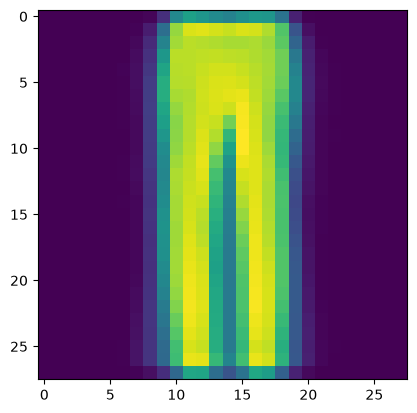

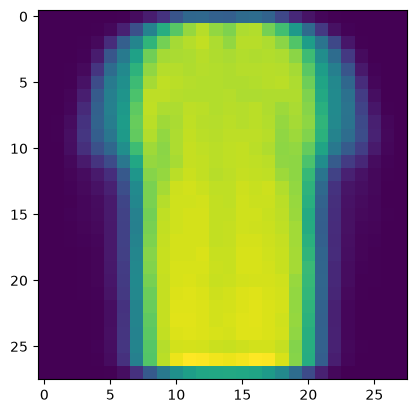

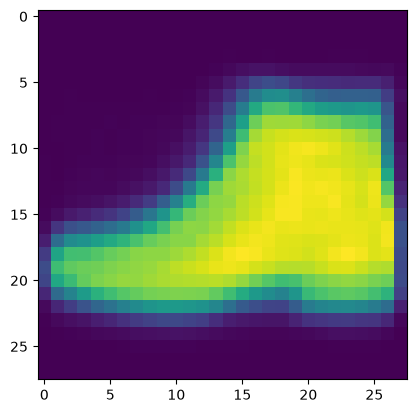

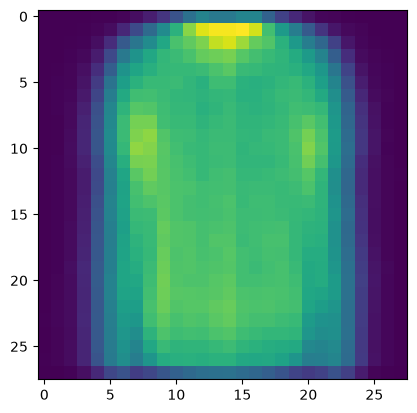

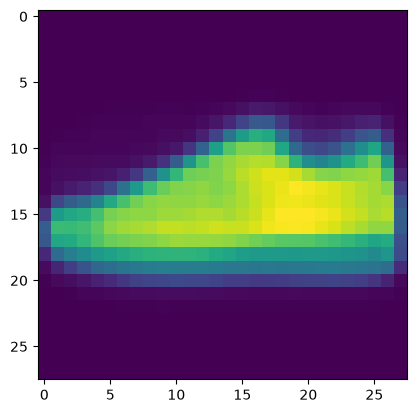

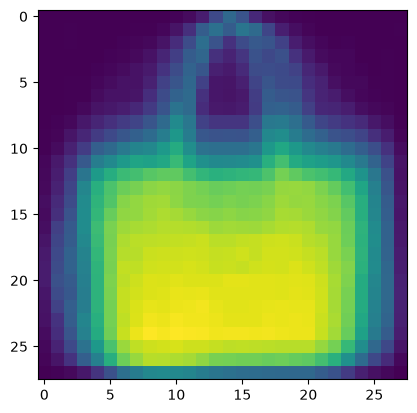

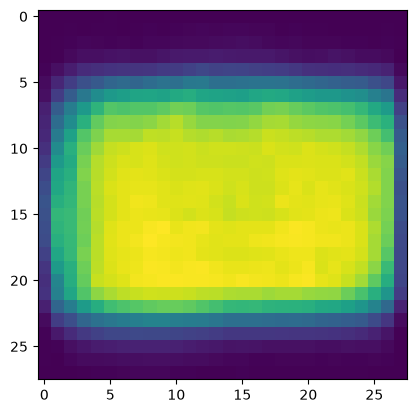

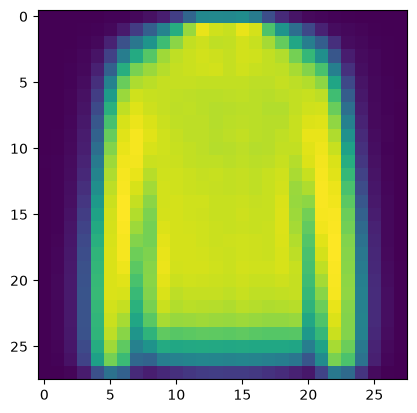

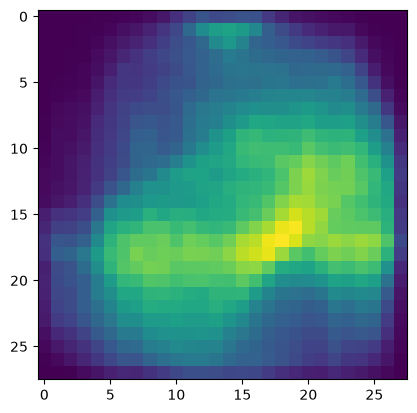

In [26]:
for iclust in range(10):
    plt.imshow(clusterer.cluster_centers_[iclust].reshape(28,28))
    plt.show()

#### Centroids in image data
A centroid is the **mean of all observations assigned to a cluster**. For image data, each observation is a vector of pixel intensities. Therefore, the centroid is the **mean pixel-intensity vector** of all images in that cluster.

If the original images are 28 × 28 pixels, the centroid can be reshaped back to 28 × 28 and visualized as an **average image of the cluster**.

<h3 style="color: #ff0000;">
  Hands-on exercise K-means – Basic: Discovering themes in text data
</h3>

In [ ]:
texts, vectors = get_nlp_dataset(data_path)

1. Explore the dataset

2. Perform a umap projection of the vectors (see previous lecture). Use metric='cosine'

3. Perform a clustering of the projected vectors. Get the optimal number of clusters with the sihouette score.

4. Try to guess the themes of the clusters by looking at the texts in each cluster.

5. Upload here https://docs.google.com/presentation/d/1g9Awv9P1O0Mg0OtFb906nLajaNxtOkxLy83g__GtinQ/edit?usp=sharing the number of clusters you found and the themes you guessed.

<h3 style="color: #ff0000;">
  Hands-on exercise K-means – Advanced: When clusters do not match classes
</h3>

Fashion-MNIST contains 10 labelled categories. Does that necessarily mean that K-means should find 10 natural clusters?

In addition to the centroid visualization that we have performed above after fitting K-means with k=10:

1. Perform a UMAP projection of the images and visualize the same embedding twice: coloured by K-means cluster and coloured by the true Fashion-MNIST label. Remember that UMAP is used here only for visualization. Compare the K-means clusters with the true categories. Do they correspond one-to-one? Which categories seem to overlap or split?

3. Calculate the silhouette score for several values of K. Does the best value correspond to K=10?

4. Summarize what this tells you about the difference between a class and a cluster.

## 2. Density-based clustering
In the previous lecture, we already used a density-based clustering method when we combined **UMAP** with **HDBSCAN** to assign cluster labels to the Ames Housing data.


### DBSCAN

DBSCAN stands for **Density-Based Spatial Clustering of Applications with Noise**. Unlike the centroid-based K-means algorithm, DBSCAN does **not require us to specify the number of clusters in advance**.

Instead, we define what it means for a region of the feature space to be sufficiently dense. Two main parameters control this:

- **`eps` ($\varepsilon$):** the maximum distance around a point within which other points are considered its neighbours.
- **`min_samples`:** the minimum number of points that must be found within this neighbourhood for the point to be considered part of a dense region.

For each point, DBSCAN therefore considers an $\varepsilon$-neighbourhood: all observations lying within distance $\varepsilon$ of that point.

Based on this neighbourhood, points can be classified as:

- **Core points:** have at least `min_samples` points within their $\varepsilon$-neighbourhood.
- **Border points:** do not themselves have enough neighbours to be core points, but lie within the neighbourhood of a core point.
- **Noise points:** are not sufficiently close to any dense region and are not assigned to a cluster.

A cluster is initialized when DBSCAN encounters a **core point that has not yet been assigned to a cluster**. The algorithm then expands the cluster by adding neighbouring points. If one of those neighbours is also a core point, its neighbourhood is explored as well. This process continues until no additional density-connected points can be added. The algorithm then searches for another unvisited core point and starts a new cluster.

This is fundamentally different from K-means. In K-means, every point is eventually assigned to one of the predefined clusters. DBSCAN can instead leave observations **unassigned as noise**, and the number of clusters emerges from the density structure of the data.

*Note: Unlike K-means, DBSCAN does **not require random initialization**, so we do not need to run it repeatedly to search for a better solution. For fixed parameters, the core points and the resulting dense regions are determined by the data. A small ambiguity can occur for **border points** that are reachable from more than one cluster: their final cluster assignment may depend on the order in which points are processed.*

### HDBSCAN

**HDBSCAN (Hierarchical DBSCAN)** extends the same density-based idea. One limitation of DBSCAN is that a single value of $\varepsilon$ defines the density threshold for the entire dataset. This can make it difficult to identify clusters when some groups are very dense while others are more spread out.

HDBSCAN explores clustering structure across **multiple density levels** and builds a hierarchy of possible clusters. It then extracts clusters that remain stable across these density levels.

As a result, HDBSCAN can often handle datasets with **clusters of different densities** more flexibly than standard DBSCAN. Instead of choosing a fixed `eps`, an important parameter becomes the minimum cluster size (`min_cluster_size`).

<h3 style="color: #ff0000;">
  DBSCAN and HDBSCAN on synthetic data
</h3>

In [ ]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.metrics import silhouette_score

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(points)


# HDBSCAN
hdbscan = HDBSCAN(min_cluster_size=5)
hdbscan_labels = hdbscan.fit_predict(points)

In [ ]:
print("DBSCAN labels:", np.unique(dbscan_labels, return_counts=True))
print("HDBSCAN labels:", np.unique(hdbscan_labels, return_counts=True))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    points[:, 0],
    points[:, 1],
    c=dbscan_labels,
    s=25,
    alpha=0.7,
)
axes[0].set(
    title="DBSCAN",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
axes[0].grid(alpha=0.3)

axes[1].scatter(
    points[:, 0],
    points[:, 1],
    c=hdbscan_labels,
    s=25,
    alpha=0.7,
)
axes[1].set(
    title="HDBSCAN",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Try changing the value of `eps` in DBSCAN.** You will see that the resulting clusters can change substantially, showing how sensitive DBSCAN is to this parameter.

HDBSCAN does not require us to choose a single `eps` value. Instead, it explores the clustering structure across different density levels. In this example, using a similar minimum cluster size leads to a more stable clustering result.

## 3. Hierarchical clustering (dendrograms)

In **agglomerative hierarchical clustering**, we start with each observation as its own cluster. We then repeatedly merge the two clusters that are most similar, until eventually all observations belong to one cluster.

As a result, hierarchical clustering builds a **nested hierarchy of clusters**, rather than producing only one fixed clustering.

The result can be visualized with a dendrogram, which shows:

- which clusters are merged at each level of the hierarchy
- the distance at which each merge occurs

The **height of a merge** therefore indicates how dissimilar the two groups were when they were joined.

The number of final clusters does not have to be chosen before fitting the model. Instead, we can choose it afterwards by cutting the dendrogram at a selected height.

How is the distance between clusters defined?

Once clusters contain more than one point, we need a rule for measuring the distance between two clusters. This is called the **linkage criterion**.

For example, with single linkage, the distance between two clusters is the distance between their closest pair of points:

$$ d(S_1,S_2)=\min_{a\in S_1,\;b\in S_2} d(a,b) $$

Other common choices for linking are:

- **Complete linkage**: distance between the farthest pair of points.
- **Average linkage**: average distance between points in the two clusters.
- **Ward linkage**: merges clusters so that the increase in within-cluster variance is as small as possible.

Different linkage criteria can produce different clustering structures.

<h3 style="color: #ff0000;">
  Hierarchical clustering on synthetic data
</h3>

Hierarchical clustering can be applied to data with any number of features. Here, we use our 2D dataset so that we can visualize both the original data and the resulting hierarchy.

The dendrogram can also be visualized for higher-dimensional datasets, even though the original feature space can no longer be displayed directly in a 2D scatter plot.

In this example, we use the hierarchical clustering and dendrogram functions from **SciPy**. Scikit-learn also provides hierarchical clustering through AgglomerativeClustering, but SciPy provides convenient functions for constructing and visualizing dendrograms.

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster import hierarchy
from ipywidgets import interact
from scipy.cluster.hierarchy import fcluster

points=km_load_th1()
Z = hierarchy.linkage(points, 'single')
n_clusters=int(np.max(Z[:,[0,1]].flatten()))
print(n_clusters)

@interact
def plot(t=(0,7,0.1)):
    fig, axes=plt.subplots(1,2,figsize=(15,10), gridspec_kw={'width_ratios': [1, 2]})
    fl = fcluster(Z,t=t,criterion='distance')
    maps={}
    for clust in range(n_clusters):
        maps[clust]=(fl==clust)
    c=0
    for clust in range(n_clusters):
        if np.sum(maps[clust])>0:
            c+=1
    plt.figure(figsize=(19,5))
    d = hierarchy.dendrogram(Z,ax=axes[1], color_threshold=t)
    axes[1].axhline(t,linestyle='--',color='red')
    axes[1].set_ylabel('Cluster distance')
    axes[1].axes.get_xaxis().set_visible(False)
    axes[1].set_xlabel('Points')
    axes[1].set_title(f'Number clusters: {c}')
    axes[0].scatter(points[d['leaves'],0],points[d['leaves'],1], color=d['leaves_color_list'])
    plt.show()

**Properties:**

If we fix a certain cutoff length $l_c$, the clusters identified $C_1,...,C_n$ at that length are such that :

1- The constintute a disjoint partition of the whole dataset, i.e. they are mutually non intersecting aand each point belongs to a cluster

2- The distance between two clusters $d(C_1,C_j)$ is larger than $l_c$ for each $i,j$.


<h3 style="color: #ff0000;">
  Explore feature correlation using dendograms
</h3>


The `points` when using dendograms can be any set of objects over which we can define a distance. They do not need to be the original dataset.

Often dendograms are used to visualize the correlation between features, and this is the goal of the present example.

Let's load a dataset of customers interactions in relation to an online program.


In [ ]:
import pandas as pd
df=get_customers_dataset(data_path=data_path)

In [ ]:
df

In [ ]:
# 1. Inspet the dataset
# 2. Perform hierarchical clustering using the "distance" 1-|r| (not really a distance), where r is the correlation coefficient
# 3. Adapt the code to visualize the dendrogram in this case. You may find the following function helpful:

import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

def get_Z_matrix_from_distance_matrix(dist_matrix, method='single'):
    """
    Perform hierarchical clustering using linkage on a distance matrix. The output of this function can be an input of the dendrogram function

    Parameters
    ----------
    dist_matrix : np.ndarray
        A square distance matrix (n_features x n_features).
    method : str, optional
        Linkage method to use (default is 'single'). See scipy.cluster.hierarchy.linkage for options.

    Returns
    -------
    Z : np.ndarray
        The linkage matrix for hierarchical clustering.
    """
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method=method) 
    return Z

# 4. Inspect the correlation between the figures. Are they stable if you change the linkage criterion?


In [ ]:
corr_matrix = np.corrcoef(df.T) 
print(corr_matrix, corr_matrix.shape)

In [ ]:
dist_matrix = 1 - np.abs(corr_matrix)

In [ ]:
Z = get_Z_matrix_from_distance_matrix(dist_matrix)

In [ ]:
# Plot the dendrogram
plt.figure(figsize=(10, 7))
feature_names=list(df.columns)
dendrogram(Z, labels=feature_names, leaf_rotation=90)
plt.title('Hierarchical Clustering of Features')
plt.xlabel('Feature Index')
plt.ylabel('Distance')
plt.show()

### Notes on the feature correlation clustering example

1. The proposed way of analyzing correlations between features can be used to interpret the output of a model. E.g. many interpretability methods struggle when correlated features are present, because they do not know to which feature to assign importance. If we have a correlation analysis we can often interpret better the features importance plot.

2. In the interactive visualization on the left plot we could visualize the scatterplot of the original points. This is not the case for the present example, because we are given as an input just the distance matrix, and not the coordinates of the points ("by any means what are the coordinates of a feature?). Nevertheless, we could obtain a useful dendrogram representation just starting from the distance matrix.



## 4. Gaussian mixtures (soft clustering)

### Theory overview.

K-Means is a modelling procedure which is biased towards clusters of circular shape and therefore does not always work perfectly, as the following examples show:

In [ ]:
points=gm_load_th1()
clusterer = KMeans(n_clusters=3, random_state=10, n_init=10)
cluster_labels=clusterer.fit_predict(points)
plt.figure(figsize=(5,5))
plt.gca().set_aspect('equal')
plt.title('K-Means')
plt.xlim(-6,6)
plt.scatter(points[:,0],points[:,1],c=cluster_labels, s=2)
plt.show()

In [ ]:
points=gm_load_th2()
clusterer = KMeans(n_clusters=2, random_state=10, n_init=10)
cluster_labels=clusterer.fit_predict(points)
plt.figure(figsize=(5,5))
plt.title('K-Means')
plt.scatter(points[:,0],points[:,1],c=cluster_labels, s=2)

A Gaussian mixture model is able to fit these kinds of clusters. In a Gaussian mixture model, each point of the distribution is supposed to be a random point from a distribution given by a superposition of Gaussians:

$$f(\mathbf{x})=\sum_c \pi_c N(\mathbf{\mu_c},\mathbf{\Sigma_c} )(\mathbf{x})$$

Each Gaussian describes the shape of each group, that may be also non spherical or tilted.

This density has the following interpretation. Suppose each data point $\hat{X}$ results from the following 2-step procedure:

1- First choose a random number between $\{1,...,N_c\}$ using some prior probabilities $\{\pi_1,...\pi_{N_c}\}$. This random variable says to what group a the point belong.

2- Now we extract the features corresponding to that point $\hat{X}$ using the corresponding density $N(\mathbf{\mu_c},\mathbf{\Sigma_c} )(\mathbf{x})$.

The parameters $\{\pi_c,\mathbf{\mu_c},\mathbf{\Sigma_c}\}$ are fitted from the data using a minimization procedure (maximum likelihood via the EM algorithm) and $N_c$ is the chosen number of clusters.



**Output of a GM computation:**

Given the features of a new point we can reverse engineer the probability that this point was extracted one group or the other.

- *Cluster probabilities:* A gaussian mixtures model is an example of soft clustering, where each data point $p$ does not get assigned a unique cluster, but a distribution over clusters $f_p(c), c=1,...,N_c$.

- *AIC/BIC:* after each clustering two numbers are returned. These can be used to select the optimal number of Gaussians to be used, similar to the Silhouette score. ( AIC and BIC consider both the likelihood of the data given the parameters and the complexity of the model related to the number of Gaussians used ). The lowest AIC or BIC value is an indication of a good fit.

<h3 style="color: #ff0000;">
  Gaussian mixture clustering on synthetic data
</h3>


First of all, we see how the Gaussian model behaves on our original example:

In [ ]:
points=km_load_th1()

aic=[]
bic=[]
sil=[]

for i_comp in range(2,6):
    plt.figure()
    plt.title(str(i_comp))
    clf = GaussianMixture(n_components=i_comp, covariance_type='full')
    clf.fit(points)
    cluster_labels=clf.predict(points)
    plt.scatter(points[:,0],points[:,1],c=cluster_labels)
    print(i_comp,clf.aic(points),clf.bic(points))
    score=silhouette_score(points,cluster_labels)
    aic.append(clf.aic(points))
    bic.append(clf.bic(points))
    sil.append(score)
    plt.show()

In [ ]:
plt.plot(np.arange(2,6),aic,'-o')
plt.title('aic')
plt.grid()
plt.show()

plt.plot(np.arange(2,6),bic,'-o')
plt.title('bic')
plt.grid()
plt.show()

plt.plot(np.arange(2,6),sil,'-o')
plt.title('silhouette')
plt.grid()
plt.show()

So in this case we get a comparable result, and also the probabilistic tools agree with the Silhouette score ! Let's see how the Gaussian mixtures behave in the examples where K-means was failing.

In [ ]:
points=gm_load_th1()
clf = GaussianMixture(n_components=3, covariance_type='full')
clf.fit(points)
cluster_labels=clf.predict(points)
plt.figure(figsize=(5,5))
plt.gca().set_aspect('equal')
plt.title('K-Means')
plt.xlim(-6,6)
plt.scatter(points[:,0],points[:,1],c=cluster_labels, s=2)
plt.show()

In [ ]:
points=gm_load_th2()
clf = GaussianMixture(n_components=2, covariance_type='full')
clf.fit(points)
cluster_labels=clf.predict(points)
plt.figure(figsize=(5,5))
plt.scatter(points[:,0],points[:,1],c=cluster_labels, s=2)
plt.show()

<h3 style="color: #ff0000;">
    Hands-on exercise Gaussian mixture clustering: Find the cluster uncertainty with Gaussian mixtures
</h3>

In this exercise you need to load the dataset used to present K-means ( def km_load_th1() ) or the one used to discuss
the Gaussian mixtures model ( def gm_load_th1() ).
As discussed, applying a fitting based on gaussian mixtures you can not only predict the cluster label for each point,
but also a probability distribution over the clusters.

From this probability distribution, you can compute for each point the entropy of the corresponging
distribution (using for example scipy.stats.entropy) as an estimation of the undertainty of the prediction.
Your task is to plot the data-cloud with a color proportional to the uncertainty of the cluster assignement.

In detail you shoud:
1. Instantiate a GaussianMixture object with the number of clusters that you expect
2. fit the object on the dataset with the fit method
3. compute the cluster probabilities using the method predict_proba. This will return a matrix of
dimension npoints x nclusters (check that this is the case!)
4. use the entropy function ( from scipy.stats you need to import the entropy
function ) to evaluate for each point the uncertainty of the
prediction. Check here if in doubt: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html
5. Plot the points colored accordingly to their uncertanty.

In [ ]:
## Some hints for your coding 1-2
points=gm_load_th1()

plt.figure()
clf = GaussianMixture(..., covariance_type='full')
clf...(...)

## Some hints for your coding 3-4
cluster_labels_prob=...

from ... import ...
entropies=[]
for point in range(len(...)):
    entropies.append(...)

## Some hints for your coding 5

cm = plt.cm.get_cmap('RdYlBu')
sc = plt.scatter(points[:,0], points[:,1], c=entropies, cmap=cm)
plt.colorbar(sc)


# Final notes

***Dimensionality reduction and clustering answer different questions.***

- **Dimensionality reduction** represents the data using fewer dimensions while trying to preserve relevant structure. It is useful for visualization, exploration, compression, and sometimes as a preprocessing step.
- **Clustering** groups observations according to a definition of similarity or structure.

The two approaches can be combined, but the distinction is important: a projection such as PCA or UMAP can be used **only for visualization**, or the projected data can themselves become the input to a clustering algorithm. These are different analyses.

***Choosing the clustering method***

There is **no universally best clustering method**. Different algorithms look for different types of structure and may therefore produce different results on the same dataset.

The result also depends on the **features, scaling, distance metric, algorithm, and parameters** used. In unsupervised learning, there are no labels telling us whether the discovered structure is "correct".

Finally, a **cluster is not necessarily a class**. Clusters describe structure in the chosen feature space. Whether that structure is meaningful has to be evaluated using measures such as the silhouette score, visualization, and, importantly, **domain knowledge**.

Unsupervised learning can help us **discover structure in data**, but interpreting that structure remains part of the analysis.


***Clustering Overview***

| Family         | Method                       | Main idea                                            |
| -------------- | ---------------------------- | ---------------------------------------------------- |
| Centroid-based | **K-means**                  | Find centres and assign points to the nearest centre |
| Density-based  | **DBSCAN / HDBSCAN**         | Find dense regions separated by sparse regions       |
| Hierarchical   | **Agglomerative clustering** | Gradually merge similar observations/clusters        |
| Model-based    | **Gaussian mixture models**  | Model data as a mixture of probability distributions |


## Solutions

**Basic: Discovering themes in text data**
1. Explore the dataset

2. Perform a umap projection of the vectors (see previous lecture). Use metric='cosine'

3. Perform a clustering of the projected vectors. Get the optimal number of clusters with the sihouette score.

4. Try to guess the themes of the clusters by looking at the texts in each cluster.

In [ ]:
texts, vectors = get_nlp_dataset(data_path)

print(len(texts))
print(vectors.shape)
print(texts[:3])

In [ ]:
umap_model = umap.UMAP(
    n_components=2,
    metric="cosine",
    random_state=42,
)

vectors_2d = umap_model.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1],
    s=25,
    alpha=0.7,
)

ax.set(
    title="UMAP projection of text embeddings",
    xlabel="UMAP dimension 1",
    ylabel="UMAP dimension 2",
)

ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(vectors_2d)
    scores.append(silhouette_score(vectors_2d, labels))

best_k = np.argmax(scores) + 2
print("Best K:", best_k)

plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

In [ ]:
clusterer = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=42,
)

labels = clusterer.fit_predict(vectors_2d)

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=25,
    alpha=0.7,
)

ax.scatter(
    clusterer.cluster_centers_[:, 0],
    clusterer.cluster_centers_[:, 1],
    marker="o",
    color="orange",
    s=100,
    edgecolors="black",
    linewidths=1,
    label="Cluster centroids",
)

ax.set(
    title="K-means clustering of text embeddings",
    xlabel="UMAP dimension 1",
    ylabel="UMAP dimension 2",
)

ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

In [ ]:
for cluster in range(best_k):
    print(f"\n--- Cluster {cluster} ---")

    cluster_texts = np.asarray(texts)[labels == cluster]

    for text in cluster_texts[:5]:
        print(text)
        print()

***--> Themes: Sports / Technology / Cooking / Space / Politics / Health***

**Advanced: Fashion MNIST clustering**

Fashion-MNIST contains 10 labelled categories. Does that necessarily mean that K-means should find 10 natural clusters?

In addition to the centroid visualization that we have performed above after fitting K-means with k=10:

1. Perform a UMAP projection of the images and visualize the same embedding twice: coloured by K-means cluster and coloured by the true Fashion-MNIST label. Remember that UMAP is used here only for visualization. Compare the K-means clusters with the true categories. Do they correspond one-to-one? Which categories seem to overlap or split?

3. Calculate the silhouette score for several values of K. Does the best value correspond to K=10?

4. Summarize what this tells you about the difference between a class and a cluster.

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans

# Reload Fashion-MNIST
X_fashion, y_fashion = fetch_openml(
    "Fashion-MNIST",
    version=1,
    as_frame=False,
    return_X_y=True,
)

X_fashion = X_fashion / 255.0
y_fashion = y_fashion.astype(int)

# Use 5,000 images
n_examples = 5000
fashion_data = X_fashion[:n_examples]
true_labels = y_fashion[:n_examples]

# Fit K-means in the original 784-dimensional pixel space
fashion_clusterer = KMeans(
    n_clusters=10,
    n_init=10,
    random_state=10,
)

cluster_labels = fashion_clusterer.fit_predict(fashion_data)

# UMAP is used ONLY for visualization
umap_model = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    random_state=1711,
    n_jobs=1,
)

fashion_2d = umap_model.fit_transform(fashion_data)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# K-means cluster assignments
scatter1 = axes[0].scatter(
    fashion_2d[:, 0],
    fashion_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=8,
    alpha=0.6,
)

axes[0].set(
    title="UMAP coloured by K-means cluster",
    xlabel="UMAP dimension 1",
    ylabel="UMAP dimension 2",
)
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].grid(alpha=0.3)

fig.colorbar(
    scatter1,
    ax=axes[0],
    label="K-means cluster",
)

# True Fashion-MNIST labels
scatter2 = axes[1].scatter(
    fashion_2d[:, 0],
    fashion_2d[:, 1],
    c=true_labels,
    cmap="tab10",
    s=8,
    alpha=0.6,
)

axes[1].set(
    title="UMAP coloured by true Fashion-MNIST label",
    xlabel="UMAP dimension 1",
    ylabel="UMAP dimension 2",
)
axes[1].set_aspect("equal", adjustable="datalim")
axes[1].grid(alpha=0.3)

fig.colorbar(
    scatter2,
    ax=axes[1],
    label="Fashion-MNIST class",
)

plt.tight_layout()
plt.show()

Note: Here, K-means was performed in the original 784-dimensional pixel space and the resulting clusters are visualized in a 2D UMAP space.

In [ ]:
silhouette_scores = []

k_values = range(2, 41)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=10,
        n_init=10
    )
    
    labels = kmeans.fit_predict(data)
    
    score = silhouette_score(
        data,
        labels,
        sample_size=1000,
        random_state=42
    )
    
    silhouette_scores.append(score)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(k_values, silhouette_scores, marker="o")

ax.set(
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
    title="Choosing K for Fashion-MNIST"
)

ax.grid(alpha=0.3)

plt.show()

Interestingly, the K-means assignments appear more spatially compact in the UMAP representation than several of the true Fashion-MNIST classes. This does not mean that the K-means clusters are "more correct". K-means groups images according to similarity in their pixel features, whereas the Fashion-MNIST labels represent semantic categories defined by humans. 

The silhouette analysis supports the same idea: the value of K that gives the most compact and well-separated clusters does not necessarily correspond to the 10 predefined classes. The example therefore illustrates that geometrically well-separated clusters do not necessarily correspond to meaningful predefined classes.

**Gaussian mixture exercise**

In [ ]:
#In this exercise you need to load the dataset used to present K-means ( def km_load_th1() ) or the one used to discuss 
# the Gaussian mixtures model ( def gm_load_th1() ). 
#As discussed, applying a fitting based on gaussian mixtures you can not only predict the cluster label for each point, 
#but also a probability distribution over the clusters. 

#From this probability distribution, you can compute for each point the entropy of the corresponging 
#distribution (using for example scipy.stats.entropy) as an estimation of the undertainty of the prediction. 
#Your task is to plot the data-cloud with a color proportional to the uncertainty of the cluster assignement.

# In detail you shoud:
# 1. Instantiate a GaussianMixture object with the number of clusters that you expect
# 2. fit the object on the dataset with the fit method 

from scipy.stats import entropy

points = gm_load_th1()

clf = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
)

clf.fit(points)

# 3. compute the cluster probabilities using the method predict_proba. This will return a matrix of 
# dimension npoints x nclusters
# 4. use the entropy function ( from scipy.stats import entropy ) to evaluate for each point the uncertainty of the 
#prediction

cluster_labels_prob = clf.predict_proba(points)

entropies = entropy(cluster_labels_prob, axis=1)

# 5. Plot the points colored accordingly to their uncertanty. 

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(
    points[:, 0],
    points[:, 1],
    c=entropies,
    cmap="RdYlBu",
    s=25,
    alpha=0.7,
)

ax.set(
    title="Gaussian mixture model: Cluster assignment uncertainty",
    xlabel="Feature 1",
    ylabel="Feature 2",
)

ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

fig.colorbar(
    scatter,
    ax=ax,
    label="Entropy",
)

plt.show()